# DoubleML Tutorial 10: Learners, Hyperparameters, And Tuning

This notebook is about the practical part of DoubleML that often decides whether an analysis feels robust or fragile: choosing nuisance learners and tuning them without letting the causal estimate become a model-selection toy.

Double machine learning separates two jobs that are easy to blur:

- The **causal estimand** is defined by the research design: treatment, outcome, controls, timing, identification assumptions, and the target population.
- The **machine-learning learners** estimate nuisance functions that make the orthogonal score usable: outcome regressions, treatment regressions, propensities, instruments, selection probabilities, or other auxiliary quantities depending on the model class.

In a partially linear regression model, the target is usually written as

\[
Y = \theta D + g_0(X) + \varepsilon,
\]

with a treatment equation

\[
D = m_0(X) + V.
\]

DoubleML estimates the nuisance functions \(g_0(X)\) and \(m_0(X)\), residualizes \(Y\) and \(D\), and then estimates \(\theta\) from an orthogonal score. The important point is that better nuisance prediction can help, but the final goal is not to win a prediction contest. The final goal is a credible estimate of \(\theta\) under valid identifying assumptions.

That creates a practical tension. Flexible models such as boosted trees can capture nonlinear confounding patterns, but they also introduce many hyperparameters. Tuning can improve nuisance quality, but careless tuning can leak information from the final estimate back into model choice. This notebook teaches a workflow that is useful in real analysis:

1. Build a numeric DoubleML backend.
2. Compare sensible learner families under common sample splits.
3. Diagnose nuisance prediction quality alongside treatment-effect estimates.
4. Use pipelines where preprocessing is part of the learner.
5. Tune hyperparameters with DoubleML's Optuna-based API.
6. Separate safe model-selection criteria from unsafe causal-estimate shopping.

Expected runtime: usually under one minute on this synthetic dataset. The Optuna section intentionally uses a small number of trials so the notebook stays tutorial-friendly.

## Setup

This cell creates the same output folders used across the DoubleML tutorial series, sets a local Matplotlib cache to avoid environment warnings, and imports the packages used in the notebook. The warning filters are intentionally narrow: they suppress known package-level noise while keeping genuine modeling problems visible.

In [1]:
from pathlib import Path
import json
import os
import time
import warnings

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "doubleml":
    PROJECT_ROOT = PROJECT_ROOT.parents[2]

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

import doubleml as dml
from doubleml import DoubleMLData, DoubleMLPLR

from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import optuna

NOTEBOOK_PREFIX = "10"
RANDOM_SEED = 42
TRUE_THETA = 1.30

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"DoubleML version: {dml.__version__}")
print(f"Output directory: {OUTPUT_DIR}")

DoubleML version: 0.11.2
Output directory: /home/apex/Documents/ranking_sys/notebooks/tutorials/doubleml/outputs


The setup confirms that the notebook is running against the local environment and that all artifacts will be written into the DoubleML tutorial output folder. Keeping outputs organized by notebook prefix makes it much easier to review the tutorial later.

## Helper Functions

The helper functions below keep the notebook focused on causal reasoning instead of repetitive file and formatting code. There are three especially important helpers:

- `make_plr_data()` creates a DoubleML-ready backend for a given dataframe.
- `fit_plr_with_learner()` fits a PLR model with common cross-fitting logic and returns both the fitted object and a compact summary row.
- `rmse_metric()` evaluates nuisance predictions from DoubleML's stored cross-fitted predictions.

The metric function is written defensively because some DoubleML model classes can contain missing nuisance targets. PLR does not usually create missing targets, but keeping the helper general makes the pattern reusable.

In [2]:
def save_table(df, filename):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    return path


def save_dataset(df, filename):
    path = DATASET_DIR / filename
    df.to_csv(path, index=False)
    return path


def rmse_metric(y_true, y_pred):
    mask = ~np.isnan(y_true)
    return mean_squared_error(y_true[mask], y_pred[mask]) ** 0.5


def mae_metric(y_true, y_pred):
    mask = ~np.isnan(y_true)
    return mean_absolute_error(y_true[mask], y_pred[mask])


def model_x_cols(df):
    excluded = {"unit_id", "outcome", "treatment", "true_g", "true_m"}
    return [col for col in df.columns if col not in excluded]


def make_plr_data(df):
    return DoubleMLData(df, y_col="outcome", d_cols="treatment", x_cols=model_x_cols(df))


def make_common_splits(df, n_folds=5, seed=RANDOM_SEED):
    splitter = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    return list(splitter.split(df))


def fit_plr_with_learner(df, learner_name, ml_l, ml_m=None, n_folds=5, seed=RANDOM_SEED):
    if ml_m is None:
        ml_m = ml_l

    dml_data = make_plr_data(df)
    sample_splits = make_common_splits(df, n_folds=n_folds, seed=seed)
    plr = DoubleMLPLR(
        dml_data,
        ml_l=clone(ml_l),
        ml_m=clone(ml_m),
        n_folds=n_folds,
        draw_sample_splitting=False,
    )
    plr.set_sample_splitting(sample_splits)

    start = time.perf_counter()
    plr.fit()
    runtime_seconds = time.perf_counter() - start

    learner_rmse = plr.evaluate_learners(metric=rmse_metric)
    learner_mae = plr.evaluate_learners(metric=mae_metric)

    row = {
        "learner": learner_name,
        "theta_hat": float(plr.coef[0]),
        "se": float(plr.se[0]),
        "ci_95_lower": float(plr.confint().iloc[0, 0]),
        "ci_95_upper": float(plr.confint().iloc[0, 1]),
        "bias_vs_true": float(plr.coef[0] - TRUE_THETA),
        "abs_bias_vs_true": float(abs(plr.coef[0] - TRUE_THETA)),
        "rmse_ml_l": float(learner_rmse["ml_l"][0, 0]),
        "rmse_ml_m": float(learner_rmse["ml_m"][0, 0]),
        "mae_ml_l": float(learner_mae["ml_l"][0, 0]),
        "mae_ml_m": float(learner_mae["ml_m"][0, 0]),
        "avg_nuisance_rmse": float((learner_rmse["ml_l"][0, 0] + learner_rmse["ml_m"][0, 0]) / 2),
        "runtime_seconds": runtime_seconds,
    }
    return plr, row


def learner_family_table():
    return pd.DataFrame(
        [
            {
                "family": "Penalized linear models",
                "examples": "RidgeCV, LassoCV",
                "strength": "Fast, stable, strong when nuisance functions are close to linear after feature engineering.",
                "watch_out": "Can underfit nonlinear confounding and make residualization too crude.",
            },
            {
                "family": "Random forests",
                "examples": "RandomForestRegressor",
                "strength": "Good default for nonlinearities and interactions with limited tuning.",
                "watch_out": "Can be slower and less smooth; shallow/deep choices matter.",
            },
            {
                "family": "Histogram gradient boosting",
                "examples": "HistGradientBoostingRegressor",
                "strength": "Strong sklearn-native boosted tree option with good speed.",
                "watch_out": "Needs regularization through depth, leaves, learning rate, and minimum leaf size.",
            },
            {
                "family": "External boosted trees",
                "examples": "LightGBM, XGBoost",
                "strength": "Flexible, fast, and common in applied data science workflows.",
                "watch_out": "Large search spaces make tuning discipline important.",
            },
        ]
    )

These helpers encode two habits that matter in DoubleML work. First, the same sample split is reused across learner comparisons, so differences are less likely to be split noise. Second, nuisance quality is summarized next to the treatment-effect estimate rather than treated as a separate modeling exercise.

## Learner Roles In DoubleML

Before we simulate data, it is worth naming what each learner is trying to learn. For PLR, `ml_l` predicts the outcome from controls and `ml_m` predicts treatment from controls. They are nuisance learners because they are not the estimand. They are tools used to form an orthogonal score.

This table is deliberately conceptual. A strong DoubleML notebook should make clear what each model is estimating before showing a single fitted coefficient.

In [3]:
nuisance_role_table = pd.DataFrame(
    [
        {
            "DoubleML model": "PLR",
            "learner": "ml_l",
            "target": "E[Y | X]",
            "why it matters": "Removes outcome variation explained by observed controls.",
        },
        {
            "DoubleML model": "PLR",
            "learner": "ml_m",
            "target": "E[D | X]",
            "why it matters": "Removes treatment variation explained by observed controls.",
        },
        {
            "DoubleML model": "IRM",
            "learner": "ml_g",
            "target": "E[Y | D, X]",
            "why it matters": "Builds potential-outcome regressions for treated and control states.",
        },
        {
            "DoubleML model": "IRM/IIVM",
            "learner": "ml_m",
            "target": "P[D = 1 | X] or P[Z = 1 | X]",
            "why it matters": "Controls weighting and overlap behavior through propensity-style models.",
        },
    ]
)

save_table(nuisance_role_table, f"{NOTEBOOK_PREFIX}_nuisance_role_table.csv")
display(nuisance_role_table)

,DoubleML model,learner,target,why it matters
0,PLR,ml_l,E[Y | X],Removes outcome variation explained by observe...
1,PLR,ml_m,E[D | X],Removes treatment variation explained by obser...
2,IRM,ml_g,"E[Y | D, X]",Builds potential-outcome regressions for treat...
3,IRM/IIVM,ml_m,P[D = 1 | X] or P[Z = 1 | X],Controls weighting and overlap behavior throug...


The key lesson is that learners are chosen for the nuisance task, not because they sound advanced. If the treatment model is hard and the outcome model is easy, it can be reasonable to use different learners for `ml_l` and `ml_m`.

## Synthetic PLR Design

We now create a synthetic PLR dataset with nonlinear confounding. The treatment is continuous, the outcome is continuous, and the true treatment effect is known: `TRUE_THETA = 1.30`.

The data intentionally contains raw categorical fields such as `segment`, `channel`, and `tenure_band`. This lets us teach a practical preprocessing point: DoubleML's backend expects the control matrix to be numeric, so categorical variables should be encoded before creating `DoubleMLData`, or handled in a way that still presents numeric controls to DoubleML.

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
n_obs = 1_400
n_numeric = 12

x_array = rng.normal(size=(n_obs, n_numeric))
raw_df = pd.DataFrame(x_array, columns=[f"x{i:02d}" for i in range(n_numeric)])
raw_df.insert(0, "unit_id", np.arange(n_obs))

raw_df["segment"] = pd.cut(
    raw_df["x00"] + 0.40 * rng.normal(size=n_obs),
    bins=[-np.inf, -0.70, 0.55, np.inf],
    labels=["low", "mid", "high"],
).astype(str)
raw_df["channel"] = rng.choice(["organic", "paid", "partner"], size=n_obs, p=[0.55, 0.30, 0.15])
raw_df["tenure_band"] = pd.cut(
    raw_df["x01"] + 0.20 * rng.normal(size=n_obs),
    bins=[-np.inf, -0.80, 0.20, 1.00, np.inf],
    labels=["new", "growing", "mature", "loyal"],
).astype(str)

segment_high = (raw_df["segment"] == "high").astype(float)
paid_channel = (raw_df["channel"] == "paid").astype(float)
loyal_tenure = (raw_df["tenure_band"] == "loyal").astype(float)

true_m = (
    0.80 * np.sin(raw_df["x00"])
    + 0.50 * raw_df["x01"] ** 2
    - 0.45 * raw_df["x02"]
    + 0.35 * segment_high
    - 0.20 * paid_channel
    + 0.40 * raw_df["x05"] * raw_df["x06"]
)
true_g = (
    1.00 * np.cos(raw_df["x00"])
    + 0.45 * raw_df["x03"] * raw_df["x04"]
    + 0.60 * np.tanh(raw_df["x07"])
    + 0.35 * loyal_tenure
    - 0.25 * paid_channel
    + 0.25 * raw_df["x08"] ** 2
)

raw_df["true_m"] = true_m
raw_df["true_g"] = true_g
raw_df["treatment"] = true_m + rng.normal(scale=1.00, size=n_obs)
raw_df["outcome"] = TRUE_THETA * raw_df["treatment"] + true_g + rng.normal(scale=1.00, size=n_obs)

save_dataset(raw_df, f"{NOTEBOOK_PREFIX}_raw_synthetic_plr_tuning_data.csv")
raw_df.head()

,unit_id,x00,x01,x02,x03,x04,x05,x06,x07,x08,x09,x10,x11,segment,channel,tenure_band,true_m,true_g,treatment,outcome
0,0,0.304717,-1.039984,0.750451,0.940565,-1.951035,-1.302180,0.127840,-0.316243,-0.016801,-0.853044,0.879398,0.777792,high,paid,new,0.526511,-0.305445,0.991977,0.377864
1,1,0.066031,1.127241,0.467509,-0.859292,0.368751,-0.958883,0.878450,-0.049926,-0.184862,-0.680930,1.222541,-0.154529,mid,paid,loyal,-0.059189,0.933844,-0.768898,1.113530
2,2,-0.428328,-0.352134,0.532309,0.365444,0.412733,0.430821,2.141648,-0.406415,-0.512243,-0.813773,0.615979,1.128972,mid,organic,growing,-0.140754,0.811879,-0.605066,0.269105
3,3,-0.113947,-0.840156,-0.824481,0.650593,0.743254,0.543154,-0.665510,0.232161,0.116686,0.218689,0.871429,0.223596,mid,organic,growing,0.488397,1.351366,1.168090,3.133282
4,4,0.678914,0.067579,0.289119,0.631288,-1.457156,-0.319671,-0.470373,-0.638878,-0.275142,1.494941,-0.865831,0.968278,mid,organic,mature,0.434684,0.044752,1.811592,3.283717


The first rows show the teaching data before encoding. The columns `true_m` and `true_g` are included only because this is a simulation; they let us build an oracle benchmark later. They must not be used as controls in the DoubleML backend.

## Data Dictionary And Audit

A learner-tuning notebook should still start with data roles. Hyperparameter tuning does not rescue a confused design. This cell records which columns are identifiers, raw controls, oracle-only simulation columns, treatment, and outcome.

In [5]:
field_dictionary = pd.DataFrame(
    [
        {"column": "unit_id", "role": "identifier", "description": "Synthetic row identifier; excluded from modeling."},
        {"column": "x00-x11", "role": "observed controls", "description": "Numeric pre-treatment controls used to create confounding."},
        {"column": "segment", "role": "observed control", "description": "Categorical control derived from x00 with noise."},
        {"column": "channel", "role": "observed control", "description": "Categorical acquisition/source-style control."},
        {"column": "tenure_band", "role": "observed control", "description": "Categorical tenure-style control derived from x01 with noise."},
        {"column": "true_m", "role": "oracle only", "description": "True treatment nuisance E[D|X] used only for simulation diagnostics."},
        {"column": "true_g", "role": "oracle only", "description": "True outcome nuisance component g0(X) used only for simulation diagnostics."},
        {"column": "treatment", "role": "treatment", "description": "Continuous treatment D."},
        {"column": "outcome", "role": "outcome", "description": "Continuous outcome Y."},
    ]
)

raw_audit = pd.DataFrame(
    {
        "n_rows": [len(raw_df)],
        "n_columns": [raw_df.shape[1]],
        "missing_cells": [int(raw_df.isna().sum().sum())],
        "true_theta": [TRUE_THETA],
        "treatment_mean": [raw_df["treatment"].mean()],
        "outcome_mean": [raw_df["outcome"].mean()],
        "corr_treatment_true_g": [raw_df["treatment"].corr(raw_df["true_g"])],
        "corr_treatment_true_m": [raw_df["treatment"].corr(raw_df["true_m"])],
    }
)

save_table(field_dictionary, f"{NOTEBOOK_PREFIX}_field_dictionary.csv")
save_table(raw_audit, f"{NOTEBOOK_PREFIX}_raw_data_audit.csv")

display(field_dictionary)
display(raw_audit)

,column,role,description
0,unit_id,identifier,Synthetic row identifier; excluded from modeling.
1,x00-x11,observed controls,Numeric pre-treatment controls used to create ...
2,segment,observed control,Categorical control derived from x00 with noise.
3,channel,observed control,Categorical acquisition/source-style control.
4,tenure_band,observed control,Categorical tenure-style control derived from ...
5,true_m,oracle only,True treatment nuisance E[D|X] used only for s...
6,true_g,oracle only,True outcome nuisance component g0(X) used onl...
7,treatment,treatment,Continuous treatment D.
8,outcome,outcome,Continuous outcome Y.


,n_rows,n_columns,missing_cells,true_theta,treatment_mean,outcome_mean,corr_treatment_true_g,corr_treatment_true_m
0,1400,20,0,1.3,0.561494,1.611073,0.019642,0.77966


The audit confirms the intended confounding structure: treatment is related to the true treatment nuisance and also correlated with outcome-relevant structure through shared controls. That is exactly the setting where residualizing with good nuisance learners matters.

## Encoding Categorical Controls For DoubleML

The raw dataframe contains strings. `DoubleMLData` validates the control matrix as numeric, so this cell one-hot encodes the categorical fields before creating the backend.

This is a common production lesson. If a learner needs preprocessing, put that preprocessing either upstream in a reproducible feature table or inside an sklearn pipeline that still receives numeric arrays from DoubleML. Do not rely on ad hoc notebook transformations that are impossible to replay.

In [6]:
encoded_df = pd.get_dummies(
    raw_df,
    columns=["segment", "channel", "tenure_band"],
    drop_first=False,
    dtype=float,
)

x_cols = model_x_cols(encoded_df)
dml_data = make_plr_data(encoded_df)

encoding_summary = pd.DataFrame(
    {
        "raw_rows": [raw_df.shape[0]],
        "raw_columns": [raw_df.shape[1]],
        "encoded_columns": [encoded_df.shape[1]],
        "model_control_columns": [len(x_cols)],
        "oracle_columns_excluded": ["true_m, true_g"],
    }
)

save_dataset(encoded_df, f"{NOTEBOOK_PREFIX}_encoded_synthetic_plr_tuning_data.csv")
save_table(encoding_summary, f"{NOTEBOOK_PREFIX}_encoding_summary.csv")

display(encoding_summary)
print(dml_data)

,raw_rows,raw_columns,encoded_columns,model_control_columns,oracle_columns_excluded
0,1400,20,27,22,"true_m, true_g"


================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: outcome
Treatment variable(s): ['treatment']
Covariates: ['x00', 'x01', 'x02', 'x03', 'x04', 'x05', 'x06', 'x07', 'x08', 'x09', 'x10', 'x11', 'segment_high', 'segment_low', 'segment_mid', 'channel_organic', 'channel_paid', 'channel_partner', 'tenure_band_growing', 'tenure_band_loyal', 'tenure_band_mature', 'tenure_band_new']
Instrument variable(s): None
No. Observations: 1400
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Columns: 27 entries, unit_id to tenure_band_new
dtypes: float64(26), int64(1)
memory usage: 295.4 KB



The backend now has a numeric control matrix and excludes the oracle simulation columns. The same feature table can be used by linear models, tree models, LightGBM, and XGBoost.

## Baseline And Oracle Benchmarks

Before comparing learners, we anchor the problem with simple benchmarks:

- A naive regression of outcome on treatment only ignores controls.
- A full linear regression adjusts linearly for encoded controls but cannot represent all nonlinear nuisance structure.
- An oracle residual regression uses the true simulated nuisance functions and gives a best-case reference that is not available in real data.

The oracle row is included for teaching only. Real applications do not know `true_m` or `true_g`.

In [7]:
def treatment_coefficient(y, d, controls=None):
    d_matrix = np.asarray(d).reshape(-1, 1)
    if controls is None:
        design = d_matrix
    else:
        design = np.column_stack([d_matrix, np.asarray(controls)])
    model = LinearRegression().fit(design, y)
    return float(model.coef_[0])

naive_theta = treatment_coefficient(raw_df["outcome"], raw_df["treatment"])
linear_adjusted_theta = treatment_coefficient(
    encoded_df["outcome"],
    encoded_df["treatment"],
    encoded_df[x_cols],
)
oracle_theta = treatment_coefficient(
    raw_df["outcome"] - raw_df["true_g"],
    raw_df["treatment"] - raw_df["true_m"],
)

baseline_table = pd.DataFrame(
    [
        {"estimator": "Naive outcome ~ treatment", "theta_hat": naive_theta, "uses_controls": False},
        {"estimator": "Full linear adjustment", "theta_hat": linear_adjusted_theta, "uses_controls": True},
        {"estimator": "Oracle residual regression", "theta_hat": oracle_theta, "uses_controls": "oracle"},
    ]
)
baseline_table["true_theta"] = TRUE_THETA
baseline_table["bias_vs_true"] = baseline_table["theta_hat"] - TRUE_THETA

save_table(baseline_table, f"{NOTEBOOK_PREFIX}_baseline_and_oracle_estimates.csv")
display(baseline_table)

,estimator,theta_hat,uses_controls,true_theta,bias_vs_true
0,Naive outcome ~ treatment,1.319604,False,1.3,0.019604
1,Full linear adjustment,1.314848,True,1.3,0.014848
2,Oracle residual regression,1.350645,oracle,1.3,0.050645


The naive estimate is not a credible causal estimate because treatment is confounded by observed controls. The oracle row shows the target we hope DoubleML approaches when the nuisance functions are learned well enough.

## Safe Tuning Workflow Diagram

This diagram summarizes the mental model for learner choice. The causal design comes first. Learners are selected to estimate nuisance functions. Cross-fitting keeps nuisance predictions out-of-sample for the score. Diagnostics and sensitivity checks then decide whether the result is stable enough to report.

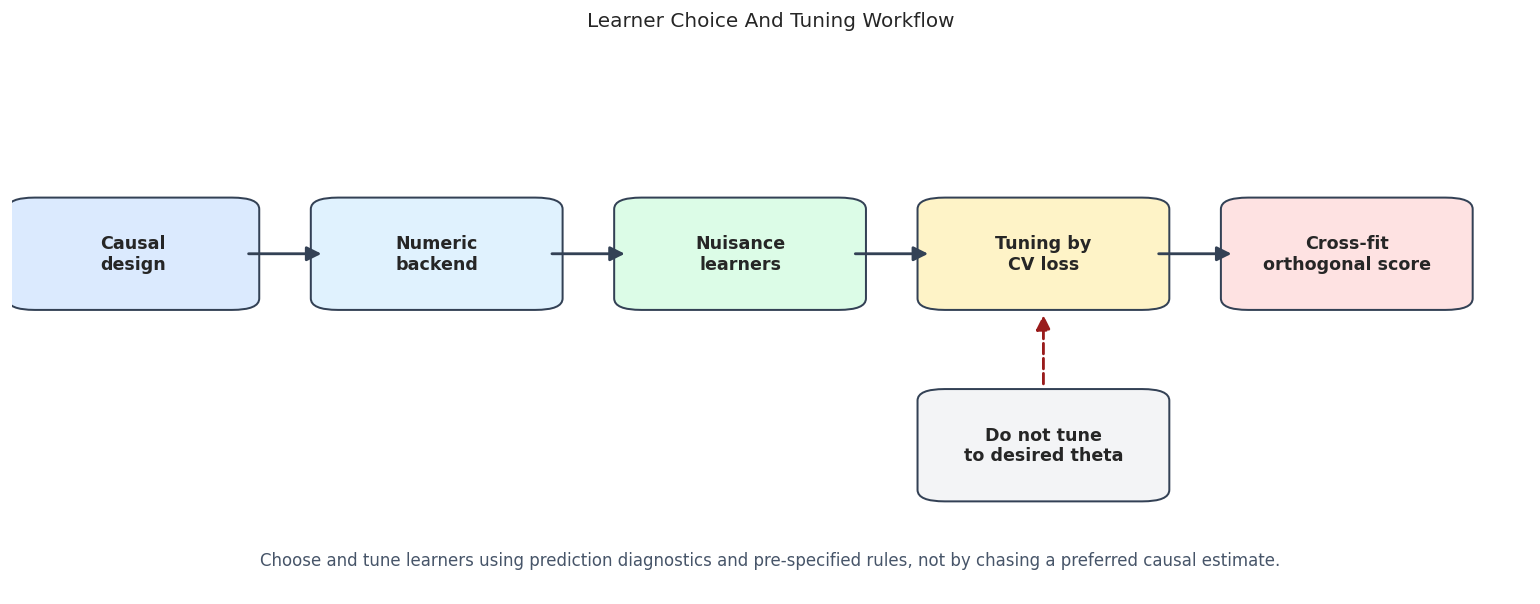

In [8]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

workflow_nodes = {
    "design": {"xy": (0.08, 0.58), "label": "Causal\ndesign", "color": "#dbeafe"},
    "backend": {"xy": (0.28, 0.58), "label": "Numeric\nbackend", "color": "#e0f2fe"},
    "learners": {"xy": (0.48, 0.58), "label": "Nuisance\nlearners", "color": "#dcfce7"},
    "tuning": {"xy": (0.68, 0.58), "label": "Tuning by\nCV loss", "color": "#fef3c7"},
    "score": {"xy": (0.88, 0.58), "label": "Cross-fit\northogonal score", "color": "#fee2e2"},
    "unsafe": {"xy": (0.68, 0.28), "label": "Do not tune\nto desired theta", "color": "#f3f4f6"},
}

fig, ax = plt.subplots(figsize=(13, 5.2))
ax.set_axis_off()
ax.set_xlim(0, 1)
ax.set_ylim(0.05, 0.90)
box_w, box_h = 0.13, 0.14


def box_anchor(name, side):
    x, y = workflow_nodes[name]["xy"]
    offsets = {"left": (-box_w / 2, 0), "right": (box_w / 2, 0), "top": (0, box_h / 2), "bottom": (0, -box_h / 2)}
    dx, dy = offsets[side]
    return (x + dx, y + dy)


def workflow_arrow(start, end, color="#334155", style="solid", rad=0.0):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=1.7,
        color=color,
        linestyle=style,
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=10,
        shrinkB=10,
        zorder=5,
    )
    ax.add_patch(arrow)

for spec in workflow_nodes.values():
    x, y = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.018",
        facecolor=spec["color"],
        edgecolor="#334155",
        linewidth=1.2,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y, spec["label"], ha="center", va="center", fontsize=10.5, fontweight="bold", zorder=4)

# Draw arrows after the boxes and leave a small gap at each endpoint so arrowheads stay visible.
for left, right in [("design", "backend"), ("backend", "learners"), ("learners", "tuning"), ("tuning", "score")]:
    workflow_arrow(box_anchor(left, "right"), box_anchor(right, "left"))

workflow_arrow(box_anchor("unsafe", "top"), box_anchor("tuning", "bottom"), color="#991b1b", style="dashed", rad=0.0)
ax.text(
    0.50,
    0.10,
    "Choose and tune learners using prediction diagnostics and pre-specified rules, not by chasing a preferred causal estimate.",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)
ax.set_title("Learner Choice And Tuning Workflow", pad=14)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_safe_tuning_workflow.png", bbox_inches="tight")
plt.show()

The diagram separates two forms of feedback. Prediction diagnostics can inform learner selection. The final causal estimate should not be repeatedly used as a steering wheel until the answer looks attractive.

## Learner Families To Compare

We define a compact learner registry. The point is not to test every model available in Python. The point is to cover the main practical families:

- regularized linear models as stable baselines,
- bagged trees,
- sklearn-native boosted trees,
- LightGBM,
- XGBoost.

All learners are configured conservatively so the notebook runs quickly and avoids extremely expressive settings that overfit a small teaching dataset.

In [9]:
learner_registry = {
    "Ridge pipeline": Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", RidgeCV(alphas=np.logspace(-3, 3, 15))),
        ]
    ),
    "LassoCV pipeline": Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", LassoCV(cv=4, random_state=RANDOM_SEED, max_iter=5_000)),
        ]
    ),
    "Random forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=7,
        min_samples_leaf=8,
        max_features=0.70,
        n_jobs=1,
        random_state=RANDOM_SEED,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=100,
        max_leaf_nodes=17,
        min_samples_leaf=20,
        learning_rate=0.06,
        random_state=RANDOM_SEED,
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=120,
        learning_rate=0.04,
        num_leaves=24,
        min_child_samples=25,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED,
        verbose=-1,
        n_jobs=1,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=120,
        max_depth=3,
        learning_rate=0.04,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=2.0,
        objective="reg:squarederror",
        random_state=RANDOM_SEED,
        n_jobs=1,
        verbosity=0,
    ),
}

family_table = learner_family_table()
pipeline_table = pd.DataFrame(
    [
        {"learner": name, "object_type": type(learner).__name__, "repr": repr(learner)[:180]}
        for name, learner in learner_registry.items()
    ]
)

save_table(family_table, f"{NOTEBOOK_PREFIX}_learner_family_table.csv")
save_table(pipeline_table, f"{NOTEBOOK_PREFIX}_learner_registry.csv")

display(family_table)
display(pipeline_table)

,family,examples,strength,watch_out
0,Penalized linear models,"RidgeCV, LassoCV","Fast, stable, strong when nuisance functions a...",Can underfit nonlinear confounding and make re...
1,Random forests,RandomForestRegressor,Good default for nonlinearities and interactio...,Can be slower and less smooth; shallow/deep ch...
2,Histogram gradient boosting,HistGradientBoostingRegressor,Strong sklearn-native boosted tree option with...,"Needs regularization through depth, leaves, le..."
3,External boosted trees,"LightGBM, XGBoost","Flexible, fast, and common in applied data sci...",Large search spaces make tuning discipline imp...


,learner,object_type,repr
0,Ridge pipeline,Pipeline,"Pipeline(steps=[('scale', StandardScaler()),\n..."
1,LassoCV pipeline,Pipeline,"Pipeline(steps=[('scale', StandardScaler()),\n..."
2,Random forest,RandomForestRegressor,"RandomForestRegressor(max_depth=7, max_feature..."
3,HistGradientBoosting,HistGradientBoostingRegressor,HistGradientBoostingRegressor(learning_rate=0....
4,LightGBM,LGBMRegressor,"LGBMRegressor(colsample_bytree=0.85, learning_..."
5,XGBoost,XGBRegressor,"XGBRegressor(base_score=None, booster=None, ca..."


The pipeline rows show an important sklearn pattern: preprocessing can be part of the learner object. For Ridge and Lasso, scaling is inside the pipeline, so every cross-fitting fold scales using only the training portion of that fold.

## Fit Learner Comparison Under Common Splits

This cell fits one PLR model per learner family. Each model uses the same K-fold sample splitting, which makes the comparison easier to read. We record the treatment effect estimate, standard error, confidence interval, cross-fitted nuisance RMSE, and runtime.

A practical warning: this is still a teaching comparison. In real work, learner selection should be planned before looking too hard at the causal estimate.

In [10]:
comparison_rows = []
fitted_models = {}

for learner_name, learner in learner_registry.items():
    fitted_model, row = fit_plr_with_learner(
        encoded_df,
        learner_name=learner_name,
        ml_l=learner,
        ml_m=learner,
        n_folds=5,
        seed=RANDOM_SEED,
    )
    fitted_models[learner_name] = fitted_model
    comparison_rows.append(row)

learner_comparison = pd.DataFrame(comparison_rows).sort_values("avg_nuisance_rmse").reset_index(drop=True)
save_table(learner_comparison, f"{NOTEBOOK_PREFIX}_learner_comparison.csv")
display(learner_comparison)

,learner,theta_hat,se,ci_95_lower,ci_95_upper,bias_vs_true,abs_bias_vs_true,rmse_ml_l,rmse_ml_m,mae_ml_l,mae_ml_m,avg_nuisance_rmse,runtime_seconds
0,HistGradientBoosting,1.260231,0.029922,1.201585,1.318877,-0.039769,0.039769,1.840439,1.114303,1.459938,0.879263,1.477371,2.927575
1,LightGBM,1.272523,0.029346,1.215006,1.330040,-0.027477,0.027477,1.849670,1.118639,1.465260,0.884099,1.484155,0.759393
2,XGBoost,1.296269,0.029296,1.238851,1.353688,-0.003731,0.003731,1.862596,1.115945,1.467989,0.881809,1.489271,0.729560
3,Random forest,1.280727,0.029370,1.223163,1.338292,-0.019273,0.019273,1.909728,1.146352,1.507496,0.903018,1.528040,4.171908
4,Ridge pipeline,1.313829,0.026528,1.261836,1.365823,0.013829,0.013829,2.022608,1.237154,1.597290,0.960121,1.629881,0.055897
5,LassoCV pipeline,1.312696,0.026267,1.261213,1.364180,0.012696,0.012696,2.023626,1.240213,1.598651,0.961691,1.631920,0.223674


The table makes the trade-off visible. Flexible learners often reduce nuisance RMSE, but the causal estimate does not move one-for-one with prediction error. Orthogonalization makes the estimate less sensitive to small nuisance errors, but it does not make learner choice irrelevant.

## Estimate Comparison Plot

The next figure puts the confidence intervals on the same axis. A useful plot for DoubleML learner comparisons should show uncertainty, not only point estimates. Otherwise, small differences between learners can look more meaningful than they are.

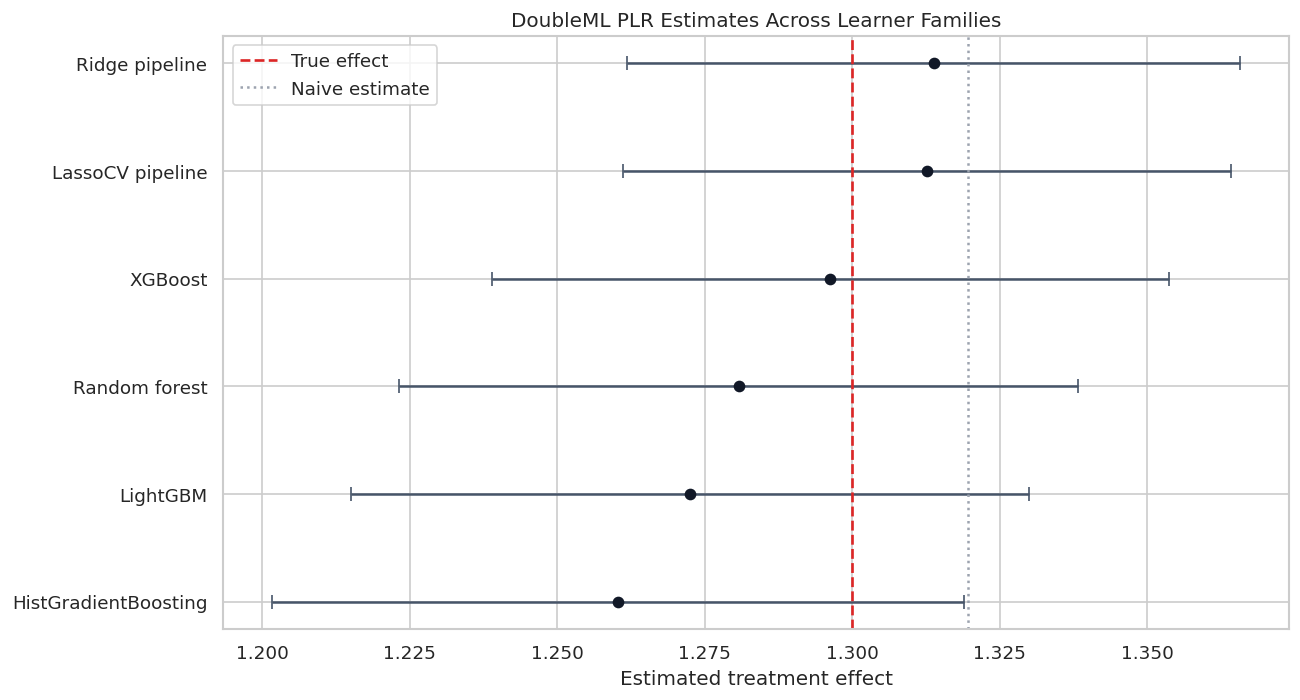

In [11]:
estimate_plot_df = learner_comparison.sort_values("theta_hat").copy()

fig, ax = plt.subplots(figsize=(11, 6))
ax.errorbar(
    x=estimate_plot_df["theta_hat"],
    y=estimate_plot_df["learner"],
    xerr=1.96 * estimate_plot_df["se"],
    fmt="o",
    color="#111827",
    ecolor="#475569",
    capsize=4,
    linewidth=1.5,
)
ax.axvline(TRUE_THETA, color="#dc2626", linestyle="--", linewidth=1.6, label="True effect")
ax.axvline(naive_theta, color="#9ca3af", linestyle=":", linewidth=1.5, label="Naive estimate")
ax.set_title("DoubleML PLR Estimates Across Learner Families")
ax.set_xlabel("Estimated treatment effect")
ax.set_ylabel("")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_learner_estimate_comparison.png", bbox_inches="tight")
plt.show()

Most learner choices recover the true effect reasonably well on this design, while the naive estimate sits elsewhere. The plot is a reminder that the main value of DoubleML is not a particular learner; it is the combination of a valid score, cross-fitting, and nuisance adjustment.

## Nuisance Quality Versus Estimate Error

This scatterplot connects predictive quality to causal accuracy in the simulation. The x-axis is average nuisance RMSE, the y-axis is absolute bias against the known true effect, and point size reflects runtime.

In real data, the y-axis is unavailable because the true effect is unknown. That is why this plot is pedagogical, not a model-selection recipe.

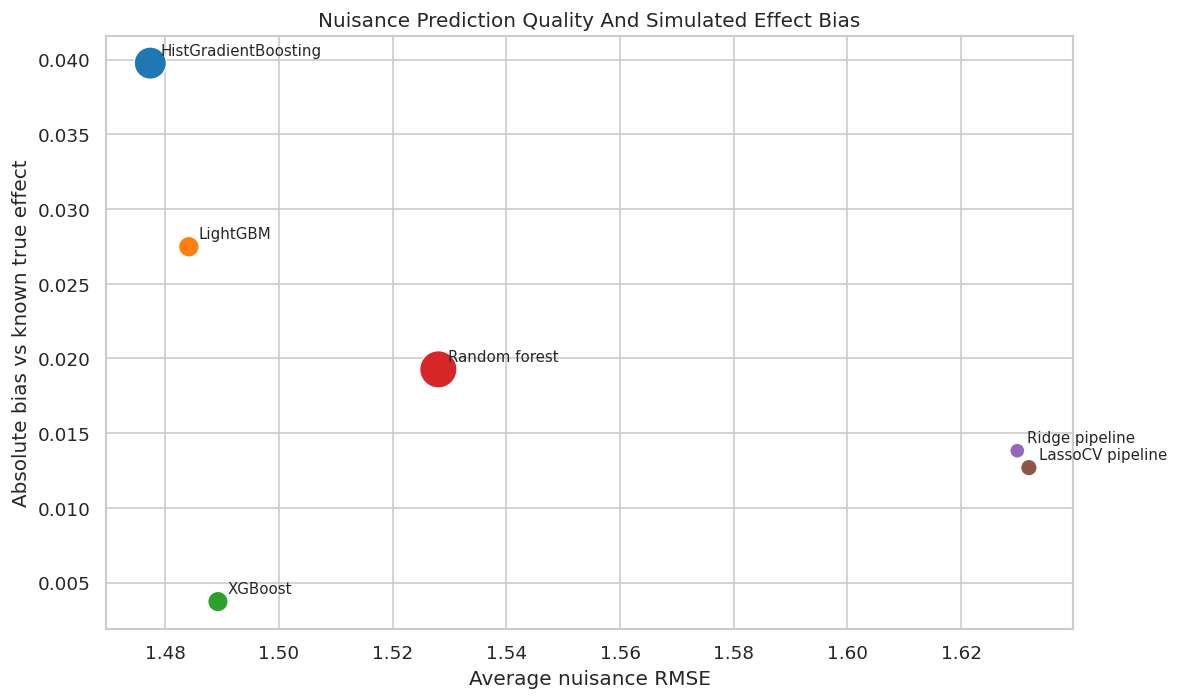

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = sns.scatterplot(
    data=learner_comparison,
    x="avg_nuisance_rmse",
    y="abs_bias_vs_true",
    size="runtime_seconds",
    sizes=(80, 500),
    hue="learner",
    palette="tab10",
    ax=ax,
)
for _, row in learner_comparison.iterrows():
    ax.annotate(
        row["learner"],
        (row["avg_nuisance_rmse"], row["abs_bias_vs_true"]),
        textcoords="offset points",
        xytext=(6, 5),
        fontsize=9,
    )
ax.set_title("Nuisance Prediction Quality And Simulated Effect Bias")
ax.set_xlabel("Average nuisance RMSE")
ax.set_ylabel("Absolute bias vs known true effect")
ax.legend_.remove()
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_nuisance_rmse_vs_bias.png", bbox_inches="tight")
plt.show()

The relationship is informative but imperfect. Better nuisance models usually help, yet finite-sample variation and regularization choices can still move the final estimate. This is why learner diagnostics should be combined with sensitivity checks and repeated sample-splitting checks in serious work.

## Inspect Cross-Fitted Nuisance Predictions

A single RMSE number can hide patterns. Here we compare observed values with cross-fitted nuisance predictions for the LightGBM model. The predictions are out-of-fold predictions created by DoubleML, which makes them the right object to inspect.

In [13]:
selected_name = "LightGBM"
selected_model = fitted_models[selected_name]

prediction_frame = pd.DataFrame(
    {
        "observed_outcome": encoded_df["outcome"].to_numpy(),
        "predicted_outcome_nuisance": selected_model.predictions["ml_l"].squeeze(),
        "observed_treatment": encoded_df["treatment"].to_numpy(),
        "predicted_treatment_nuisance": selected_model.predictions["ml_m"].squeeze(),
    }
)

prediction_quality = pd.DataFrame(
    [
        {
            "learner": selected_name,
            "nuisance": "ml_l outcome model",
            "rmse": rmse_metric(prediction_frame["observed_outcome"], prediction_frame["predicted_outcome_nuisance"]),
            "mae": mean_absolute_error(prediction_frame["observed_outcome"], prediction_frame["predicted_outcome_nuisance"]),
            "r2": r2_score(prediction_frame["observed_outcome"], prediction_frame["predicted_outcome_nuisance"]),
        },
        {
            "learner": selected_name,
            "nuisance": "ml_m treatment model",
            "rmse": rmse_metric(prediction_frame["observed_treatment"], prediction_frame["predicted_treatment_nuisance"]),
            "mae": mean_absolute_error(prediction_frame["observed_treatment"], prediction_frame["predicted_treatment_nuisance"]),
            "r2": r2_score(prediction_frame["observed_treatment"], prediction_frame["predicted_treatment_nuisance"]),
        },
    ]
)

save_table(prediction_quality, f"{NOTEBOOK_PREFIX}_selected_nuisance_prediction_quality.csv")
display(prediction_quality)

,learner,nuisance,rmse,mae,r2
0,LightGBM,ml_l outcome model,1.849670,1.465260,0.428331
1,LightGBM,ml_m treatment model,1.118639,0.884099,0.497622


The outcome nuisance is harder than the treatment nuisance in this synthetic design because the outcome contains treatment-driven variation and a nonlinear baseline component. Seeing this split helps decide where tuning effort should go.

## Nuisance Prediction Scatterplots

The scatterplots below show where the selected learner fits well and where it struggles. For a real analysis, this type of plot is not proof of causal validity, but it can reveal obvious underfitting or data-quality issues.

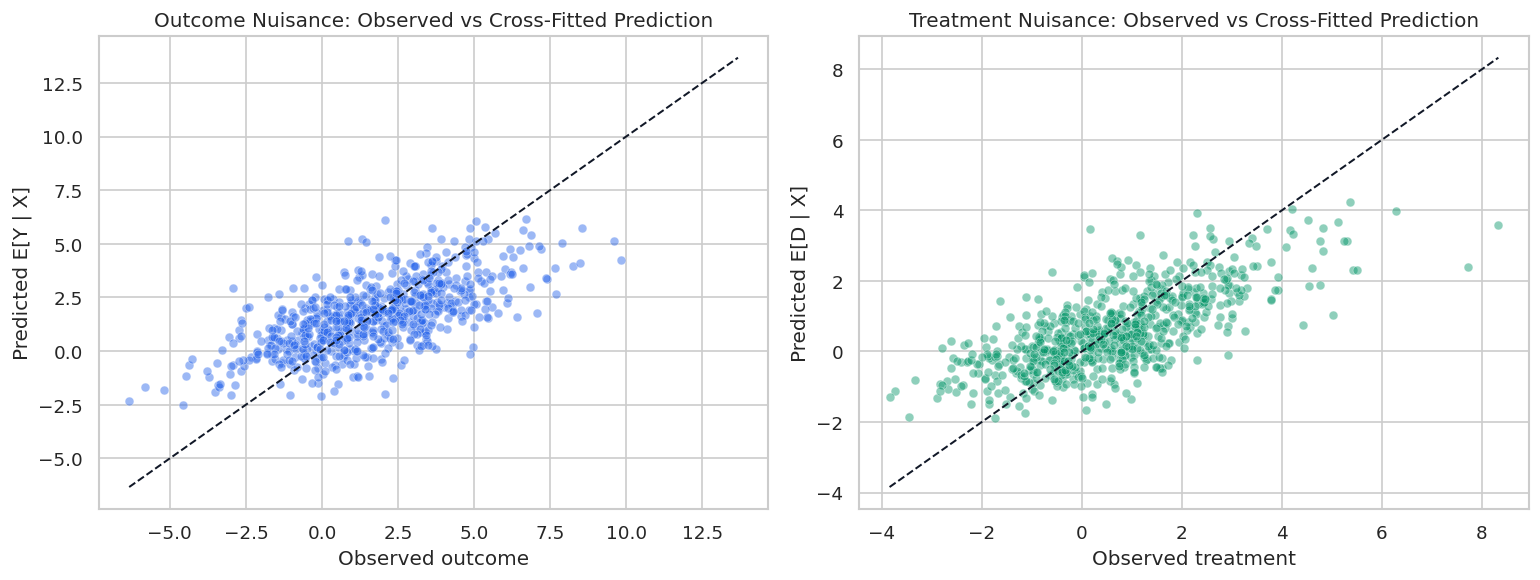

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=prediction_frame.sample(700, random_state=RANDOM_SEED),
    x="observed_outcome",
    y="predicted_outcome_nuisance",
    alpha=0.45,
    s=28,
    color="#2563eb",
    ax=axes[0],
)
axes[0].plot(
    [prediction_frame["observed_outcome"].min(), prediction_frame["observed_outcome"].max()],
    [prediction_frame["observed_outcome"].min(), prediction_frame["observed_outcome"].max()],
    color="#111827",
    linestyle="--",
    linewidth=1.2,
)
axes[0].set_title("Outcome Nuisance: Observed vs Cross-Fitted Prediction")
axes[0].set_xlabel("Observed outcome")
axes[0].set_ylabel("Predicted E[Y | X]")

sns.scatterplot(
    data=prediction_frame.sample(700, random_state=RANDOM_SEED + 1),
    x="observed_treatment",
    y="predicted_treatment_nuisance",
    alpha=0.45,
    s=28,
    color="#059669",
    ax=axes[1],
)
axes[1].plot(
    [prediction_frame["observed_treatment"].min(), prediction_frame["observed_treatment"].max()],
    [prediction_frame["observed_treatment"].min(), prediction_frame["observed_treatment"].max()],
    color="#111827",
    linestyle="--",
    linewidth=1.2,
)
axes[1].set_title("Treatment Nuisance: Observed vs Cross-Fitted Prediction")
axes[1].set_xlabel("Observed treatment")
axes[1].set_ylabel("Predicted E[D | X]")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_selected_nuisance_prediction_scatter.png", bbox_inches="tight")
plt.show()

The treatment nuisance predictions are tighter because the treatment equation is easier to learn. The outcome nuisance remains noisier, which is normal when the outcome contains both treatment variation and irreducible noise.

## Library-Native Hyperparameter Tuning With Optuna

DoubleML provides `tune_ml_models()`, which uses Optuna to tune nuisance learners. The parameter spaces are functions that receive an Optuna trial and return a parameter dictionary.

This section tunes a LightGBM learner for both `ml_l` and `ml_m`. The search is intentionally small: enough to teach the workflow, not enough to spend minutes chasing marginal improvements.

Important distinction: tuning is based on nuisance prediction scores, here negative root mean squared error. We are not asking Optuna to optimize the treatment-effect estimate.

In [15]:
base_lgbm_for_tuning = LGBMRegressor(
    n_estimators=120,
    random_state=RANDOM_SEED,
    verbose=-1,
    n_jobs=1,
)

def lgbm_param_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 40),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 60),
        "subsample": trial.suggest_float("subsample", 0.70, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.70, 1.00),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.10, 5.00, log=True),
    }

untuned_lgbm_model, untuned_lgbm_row = fit_plr_with_learner(
    encoded_df,
    learner_name="LightGBM untuned reference",
    ml_l=base_lgbm_for_tuning,
    ml_m=base_lgbm_for_tuning,
    n_folds=5,
    seed=RANDOM_SEED,
)

tuned_lgbm = DoubleMLPLR(
    make_plr_data(encoded_df),
    ml_l=clone(base_lgbm_for_tuning),
    ml_m=clone(base_lgbm_for_tuning),
    n_folds=5,
    draw_sample_splitting=False,
)
tuned_lgbm.set_sample_splitting(make_common_splits(encoded_df, n_folds=5, seed=RANDOM_SEED))

tune_start = time.perf_counter()
tune_result = tuned_lgbm.tune_ml_models(
    ml_param_space={"ml_l": lgbm_param_space, "ml_m": lgbm_param_space},
    scoring_methods={"ml_l": "neg_root_mean_squared_error", "ml_m": "neg_root_mean_squared_error"},
    cv=3,
    set_as_params=True,
    return_tune_res=True,
    optuna_settings={
        "n_trials": 10,
        "direction": "maximize",
        "show_progress_bar": False,
        "sampler": optuna.samplers.TPESampler(seed=RANDOM_SEED),
    },
)
tuning_runtime = time.perf_counter() - tune_start

tuned_fit_start = time.perf_counter()
tuned_lgbm.fit()
tuned_fit_runtime = time.perf_counter() - tuned_fit_start

tuned_rmse = tuned_lgbm.evaluate_learners(metric=rmse_metric)
tuned_mae = tuned_lgbm.evaluate_learners(metric=mae_metric)

tuned_lgbm_row = {
    "learner": "LightGBM tuned with tune_ml_models",
    "theta_hat": float(tuned_lgbm.coef[0]),
    "se": float(tuned_lgbm.se[0]),
    "ci_95_lower": float(tuned_lgbm.confint().iloc[0, 0]),
    "ci_95_upper": float(tuned_lgbm.confint().iloc[0, 1]),
    "bias_vs_true": float(tuned_lgbm.coef[0] - TRUE_THETA),
    "abs_bias_vs_true": float(abs(tuned_lgbm.coef[0] - TRUE_THETA)),
    "rmse_ml_l": float(tuned_rmse["ml_l"][0, 0]),
    "rmse_ml_m": float(tuned_rmse["ml_m"][0, 0]),
    "mae_ml_l": float(tuned_mae["ml_l"][0, 0]),
    "mae_ml_m": float(tuned_mae["ml_m"][0, 0]),
    "avg_nuisance_rmse": float((tuned_rmse["ml_l"][0, 0] + tuned_rmse["ml_m"][0, 0]) / 2),
    "runtime_seconds": tuned_fit_runtime,
    "tuning_runtime_seconds": tuning_runtime,
}

print(f"Tuning runtime: {tuning_runtime:.2f} seconds")
print(f"Final tuned fit runtime: {tuned_fit_runtime:.2f} seconds")

Tuning runtime: 3.72 seconds
Final tuned fit runtime: 0.68 seconds


The tuning cell separates two costs: the Optuna search time and the final DoubleML fit time. In a real workflow, the search budget should be decided before the analysis begins, especially when many learners and outcomes are being compared.

## Tuning Result Details

The returned Optuna objects contain the best parameters and the nuisance score for each learner. We flatten them into a table so the chosen hyperparameters become part of the audit trail.

In [16]:
tune_rows = []
for result_bundle in tune_result:
    for learner_key, result in result_bundle.items():
        tune_rows.append(
            {
                "learner_key": learner_key,
                "best_score_neg_rmse": float(result.best_score),
                "best_rmse": float(-result.best_score),
                "best_params": json.dumps(result.best_params, sort_keys=True),
            }
        )

tune_summary = pd.DataFrame(tune_rows)
tuned_comparison = pd.DataFrame([untuned_lgbm_row, tuned_lgbm_row])

save_table(tune_summary, f"{NOTEBOOK_PREFIX}_optuna_tune_summary.csv")
save_table(tuned_comparison, f"{NOTEBOOK_PREFIX}_tuned_vs_untuned_lgbm.csv")

display(tune_summary)
display(tuned_comparison)

,learner_key,best_score_neg_rmse,best_rmse,best_params
0,ml_l,-1.851373,1.851373,"{""colsample_bytree"": 0.9896896099223678, ""lear..."
1,ml_m,-1.124470,1.124470,"{""colsample_bytree"": 0.7094287557060203, ""lear..."


,learner,theta_hat,se,ci_95_lower,ci_95_upper,bias_vs_true,abs_bias_vs_true,rmse_ml_l,rmse_ml_m,mae_ml_l,mae_ml_m,avg_nuisance_rmse,runtime_seconds,tuning_runtime_seconds
0,LightGBM untuned reference,1.219688,0.029935,1.161017,1.278359,-0.080312,0.080312,1.858091,1.135388,1.479899,0.896752,1.49674,1.05248,NaN
1,LightGBM tuned with tune_ml_models,1.247427,0.029360,1.189881,1.304972,-0.052573,0.052573,1.825092,1.116527,1.444504,0.878563,1.47081,0.67705,3.717984


The tuned model may or may not dominate the untuned reference on every metric. That is normal. Tuning is a disciplined way to search the learner space, not a guarantee that every finite-sample estimate improves.

## Tuned Versus Untuned Plot

This plot compares the LightGBM reference with the tuned LightGBM model. The useful question is not simply which point is closer to the true effect in this simulation. The useful question is whether tuning improves nuisance quality enough to justify the extra complexity and runtime.

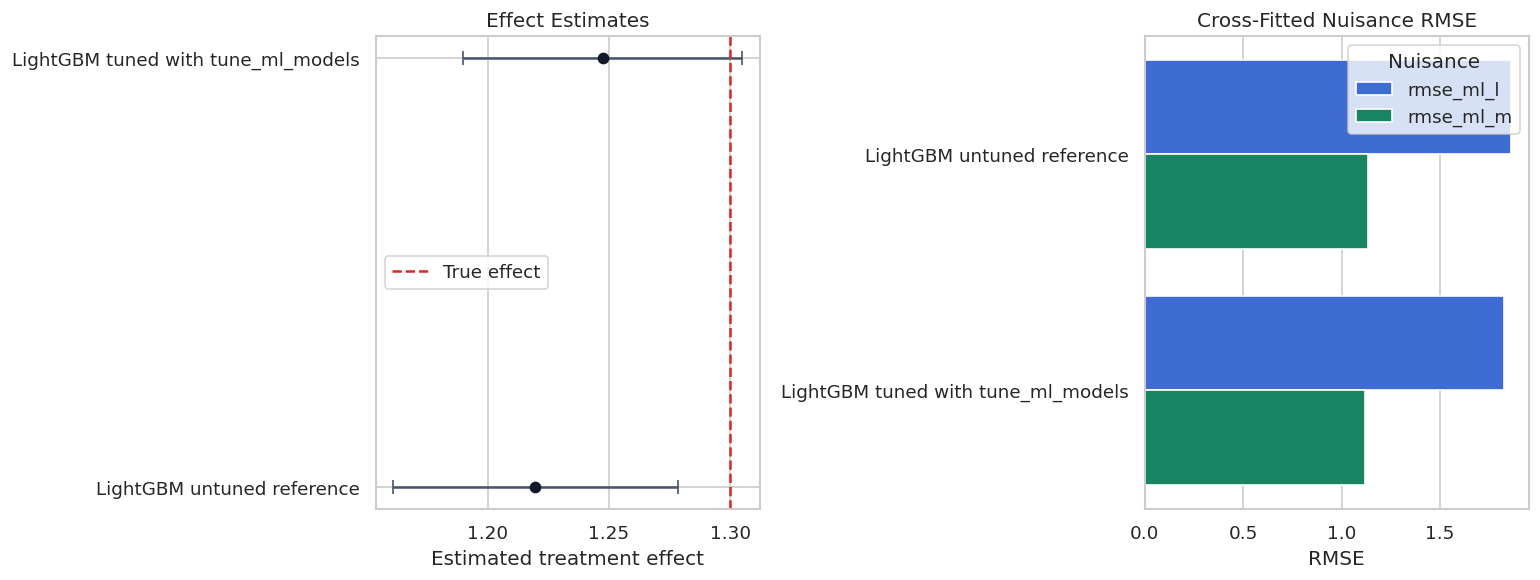

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_tuned = tuned_comparison.copy()
axes[0].errorbar(
    x=plot_tuned["theta_hat"],
    y=plot_tuned["learner"],
    xerr=1.96 * plot_tuned["se"],
    fmt="o",
    color="#111827",
    ecolor="#475569",
    capsize=4,
)
axes[0].axvline(TRUE_THETA, color="#dc2626", linestyle="--", linewidth=1.5, label="True effect")
axes[0].set_title("Effect Estimates")
axes[0].set_xlabel("Estimated treatment effect")
axes[0].set_ylabel("")
axes[0].legend(loc="best")

bar_df = plot_tuned.melt(
    id_vars="learner",
    value_vars=["rmse_ml_l", "rmse_ml_m"],
    var_name="nuisance",
    value_name="rmse",
)
sns.barplot(data=bar_df, x="rmse", y="learner", hue="nuisance", ax=axes[1], palette=["#2563eb", "#059669"])
axes[1].set_title("Cross-Fitted Nuisance RMSE")
axes[1].set_xlabel("RMSE")
axes[1].set_ylabel("")
axes[1].legend(title="Nuisance")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_tuned_vs_untuned_lgbm.png", bbox_inches="tight")
plt.show()

The side-by-side view keeps causal and predictive diagnostics together. When tuning changes the causal estimate, the next question should be whether the nuisance predictions, overlap, residuals, or sensitivity checks explain why.

## Honest Learner Selection Split

When many learner families are compared, there is a risk of choosing the model because the final estimate looks convenient. One practical discipline is to use an exploration split to choose a learner by nuisance criteria, then run the final estimate on a separate estimation split.

This is not mandatory for every DoubleML analysis, and it costs sample size. But it is a useful teaching device for separating model selection from final effect reporting.

In [18]:
exploration_df, estimation_df = train_test_split(
    encoded_df,
    test_size=0.60,
    random_state=RANDOM_SEED,
    shuffle=True,
)

honest_candidate_names = ["LassoCV pipeline", "HistGradientBoosting", "LightGBM", "XGBoost"]
honest_rows = []
for learner_name in honest_candidate_names:
    _, row = fit_plr_with_learner(
        exploration_df.reset_index(drop=True),
        learner_name=learner_name,
        ml_l=learner_registry[learner_name],
        ml_m=learner_registry[learner_name],
        n_folds=3,
        seed=RANDOM_SEED,
    )
    honest_rows.append(row)

exploration_selection = pd.DataFrame(honest_rows).sort_values("avg_nuisance_rmse").reset_index(drop=True)
selected_honest_learner = exploration_selection.loc[0, "learner"]

final_honest_model, final_honest_row = fit_plr_with_learner(
    estimation_df.reset_index(drop=True),
    learner_name=f"Honest selected: {selected_honest_learner}",
    ml_l=learner_registry[selected_honest_learner],
    ml_m=learner_registry[selected_honest_learner],
    n_folds=5,
    seed=RANDOM_SEED + 7,
)

honest_final_table = pd.DataFrame([final_honest_row])

save_table(exploration_selection, f"{NOTEBOOK_PREFIX}_honest_exploration_selection.csv")
save_table(honest_final_table, f"{NOTEBOOK_PREFIX}_honest_final_estimate.csv")

display(exploration_selection)
display(honest_final_table)

,learner,theta_hat,se,ci_95_lower,ci_95_upper,bias_vs_true,abs_bias_vs_true,rmse_ml_l,rmse_ml_m,mae_ml_l,mae_ml_m,avg_nuisance_rmse,runtime_seconds
0,XGBoost,1.313994,0.039975,1.235644,1.392344,0.013994,0.013994,1.906027,1.151033,1.506946,0.913160,1.528530,0.314751
1,LightGBM,1.276176,0.040285,1.197220,1.355133,-0.023824,0.023824,1.936377,1.195060,1.528350,0.950518,1.565718,0.151945
2,HistGradientBoosting,1.254986,0.043235,1.170248,1.339725,-0.045014,0.045014,1.959175,1.207533,1.547991,0.965919,1.583354,0.946530
3,LassoCV pipeline,1.337713,0.037976,1.263281,1.412144,0.037713,0.037713,1.990969,1.204897,1.586644,0.955102,1.597933,0.237831


,learner,theta_hat,se,ci_95_lower,ci_95_upper,bias_vs_true,abs_bias_vs_true,rmse_ml_l,rmse_ml_m,mae_ml_l,mae_ml_m,avg_nuisance_rmse,runtime_seconds
0,Honest selected: XGBoost,1.303025,0.038108,1.228335,1.377714,0.003025,0.003025,1.918942,1.148045,1.518586,0.897994,1.533493,0.582215


The exploration split chooses a learner using nuisance RMSE, then the estimation split reports the treatment effect. This is more conservative than selecting the final model after browsing all causal estimates.

## Unsafe Tuning Patterns

The next table is not code for fitting a model. It is a checklist of habits to avoid. These mistakes are common because they feel like ordinary machine-learning iteration, but they weaken the credibility of causal reporting.

In [19]:
unsafe_patterns = pd.DataFrame(
    [
        {
            "pattern": "Choose the learner whose theta is closest to a preferred answer",
            "why_it_is_unsafe": "The final estimate becomes part of the selection rule, so uncertainty is understated and the design is no longer pre-specified.",
            "safer_alternative": "Choose learners using nuisance prediction, stability rules, or an honest exploration split.",
        },
        {
            "pattern": "Tune on the full analysis until confidence intervals become significant",
            "why_it_is_unsafe": "Repeated searching changes the meaning of the reported interval.",
            "safer_alternative": "Fix the tuning budget and report sensitivity to reasonable alternatives.",
        },
        {
            "pattern": "Preprocess using outcome information outside a fold",
            "why_it_is_unsafe": "Information from held-out rows can leak into nuisance predictions.",
            "safer_alternative": "Put preprocessing inside sklearn pipelines or build reproducible pre-treatment features only.",
        },
        {
            "pattern": "Report only the best-looking learner",
            "why_it_is_unsafe": "Readers cannot see whether the result is stable across defensible choices.",
            "safer_alternative": "Show a compact learner sensitivity table and explain the chosen primary specification.",
        },
    ]
)

save_table(unsafe_patterns, f"{NOTEBOOK_PREFIX}_unsafe_tuning_patterns.csv")
display(unsafe_patterns)

,pattern,why_it_is_unsafe,safer_alternative
0,Choose the learner whose theta is closest to a...,The final estimate becomes part of the selecti...,"Choose learners using nuisance prediction, sta..."
1,Tune on the full analysis until confidence int...,Repeated searching changes the meaning of the ...,Fix the tuning budget and report sensitivity t...
2,Preprocess using outcome information outside a...,Information from held-out rows can leak into n...,Put preprocessing inside sklearn pipelines or ...
3,Report only the best-looking learner,Readers cannot see whether the result is stabl...,Show a compact learner sensitivity table and e...


The safe alternative is not to avoid tuning. The safe alternative is to make tuning auditable: define the search space, define the score, control the search budget, and show robustness to plausible learner choices.

## Reporting Checklist

A good learner-tuning section in a causal notebook should be short but complete. The table below is a reusable reporting checklist.

In [20]:
reporting_checklist = pd.DataFrame(
    [
        {"item": "State the causal estimand before learner selection", "status": "required"},
        {"item": "List the nuisance learners and their targets", "status": "required"},
        {"item": "Describe preprocessing and confirm controls are pre-treatment", "status": "required"},
        {"item": "Report cross-fitting folds and repeated-split choices", "status": "required"},
        {"item": "Show nuisance prediction diagnostics", "status": "recommended"},
        {"item": "Show effect stability across a small set of defensible learners", "status": "recommended"},
        {"item": "Document tuning search spaces, scores, and trial budgets", "status": "required if tuned"},
        {"item": "Avoid choosing models based on desired treatment-effect estimates", "status": "required"},
    ]
)

save_table(reporting_checklist, f"{NOTEBOOK_PREFIX}_learner_tuning_reporting_checklist.csv")
display(reporting_checklist)

,item,status
0,State the causal estimand before learner selec...,required
1,List the nuisance learners and their targets,required
2,Describe preprocessing and confirm controls ar...,required
3,Report cross-fitting folds and repeated-split ...,required
4,Show nuisance prediction diagnostics,recommended
5,Show effect stability across a small set of de...,recommended
6,"Document tuning search spaces, scores, and tri...",required if tuned
7,Avoid choosing models based on desired treatme...,required


This checklist is intentionally practical. It turns learner choice from a hidden modeling preference into a reproducible part of the causal analysis.

## Report Template

The final cell writes a short report template. The template is not meant to replace analysis; it is meant to keep the final write-up disciplined and consistent.

In [21]:
report_text = f"""
# Learner And Tuning Report Template

## Estimand
- Treatment:
- Outcome:
- Control set:
- Target population:
- Identification assumptions:

## Nuisance Learners
- Primary `ml_l` learner:
- Primary `ml_m` learner:
- Reason for primary learner choice:
- Alternative learners checked:

## Preprocessing
- Numeric controls:
- Encoded categorical controls:
- Excluded columns:
- Pipeline steps:

## Cross-Fitting And Tuning
- Number of folds:
- Repeated sample splitting:
- Tuning method:
- Tuning score:
- Search budget:
- Search space summary:

## Diagnostics
- Outcome nuisance RMSE:
- Treatment nuisance RMSE:
- Estimate stability across learners:
- Runtime considerations:

## Final Estimate
- Point estimate:
- Standard error:
- Confidence interval:
- Main caveats:
""".strip()

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_learner_tuning_report_template.md"
report_path.write_text(report_text)

artifact_manifest = pd.DataFrame(
    [
        {"artifact": "raw synthetic data", "path": str(DATASET_DIR / f"{NOTEBOOK_PREFIX}_raw_synthetic_plr_tuning_data.csv")},
        {"artifact": "encoded synthetic data", "path": str(DATASET_DIR / f"{NOTEBOOK_PREFIX}_encoded_synthetic_plr_tuning_data.csv")},
        {"artifact": "learner comparison", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_learner_comparison.csv")},
        {"artifact": "Optuna tuning summary", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_optuna_tune_summary.csv")},
        {"artifact": "report template", "path": str(report_path)},
        {"artifact": "workflow figure", "path": str(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_safe_tuning_workflow.png")},
        {"artifact": "estimate comparison figure", "path": str(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_learner_estimate_comparison.png")},
    ]
)

save_table(artifact_manifest, f"{NOTEBOOK_PREFIX}_artifact_manifest.csv")
display(Markdown(f"Report template written to `{report_path}`"))
display(artifact_manifest)

Report template written to `/home/apex/Documents/ranking_sys/notebooks/tutorials/doubleml/outputs/reports/10_learner_tuning_report_template.md`

,artifact,path
0,raw synthetic data,/home/apex/Documents/ranking_sys/notebooks/tut...
1,encoded synthetic data,/home/apex/Documents/ranking_sys/notebooks/tut...
2,learner comparison,/home/apex/Documents/ranking_sys/notebooks/tut...
3,Optuna tuning summary,/home/apex/Documents/ranking_sys/notebooks/tut...
4,report template,/home/apex/Documents/ranking_sys/notebooks/tut...
5,workflow figure,/home/apex/Documents/ranking_sys/notebooks/tut...
6,estimate comparison figure,/home/apex/Documents/ranking_sys/notebooks/tut...


The notebook now has all pieces needed for a learner-tuning tutorial: a known synthetic target, learner-family comparison, nuisance diagnostics, library-native tuning, an honest-selection pattern, and reporting artifacts.

## What Comes Next

The natural next topic is sample splitting itself: how cross-fitting works, what repeated cross-fitting changes, how to inspect split stability, and when repeated sample splits are worth the extra runtime.